# Multilayer generation sanity check

Loads the 1,000-samples-per-layer-count RBS experiment from `examples/datasets/iba_multilayer_small_seed_1` and checks sample counts, compositions, thicknesses, and spectra.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().resolve()
if ROOT.name == 'examples':
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import ibeamlab as ibl

DATA_ROOT = ROOT / 'examples' / 'datasets' / 'iba_multilayer_small_seed_1'
if not DATA_ROOT.is_dir():
    raise FileNotFoundError(f'Run `python examples/generate_multilayer.py examples/multilayer-generation-small.toml` first; missing {DATA_ROOT}')

## Load each layer-count dataset

Each folder should contain 1,000 generated samples, with one RBS spectrum per sample.

In [2]:
datasets = {}
for layer_count in range(1, 11):
    path = DATA_ROOT / f'layers_{layer_count:02d}'
    dataset = ibl.open_dataset(path)
    datasets[layer_count] = dataset
    print(
        f'{layer_count:2d} layers: {dataset.metadata.accepted:,} accepted / '
        f'{dataset.metadata.requested:,} requested; '
        f'{dataset.metadata.invalid} invalid, {dataset.metadata.failed} failed; '
        f'complete={dataset.metadata.complete}'
    )

assert all(ds.metadata.complete for ds in datasets.values())
assert all(ds.metadata.requested == 1_000 for ds in datasets.values())
assert all(ds.metadata.spectrum_labels == ('RBS',) for ds in datasets.values())

 1 layers: 1,000 accepted / 1,000 requested; 0 invalid, 0 failed; complete=True
 2 layers: 1,000 accepted / 1,000 requested; 0 invalid, 0 failed; complete=True
 3 layers: 1,000 accepted / 1,000 requested; 0 invalid, 0 failed; complete=True
 4 layers: 1,000 accepted / 1,000 requested; 0 invalid, 0 failed; complete=True
 5 layers: 1,000 accepted / 1,000 requested; 0 invalid, 0 failed; complete=True
 6 layers: 1,000 accepted / 1,000 requested; 0 invalid, 0 failed; complete=True
 7 layers: 1,000 accepted / 1,000 requested; 0 invalid, 0 failed; complete=True
 8 layers: 1,000 accepted / 1,000 requested; 0 invalid, 0 failed; complete=True
 9 layers: 1,000 accepted / 1,000 requested; 0 invalid, 0 failed; complete=True
10 layers: 1,000 accepted / 1,000 requested; 0 invalid, 0 failed; complete=True


## Check layer thicknesses and normalized compositions

The per-layer thickness ranges should generally widen with depth. Individual sampled thicknesses are random, so they are not required to increase monotonically within a sample. Each layer’s element fractions should sum to one.

Maximum absolute composition-sum error: 4.440892098500626e-16


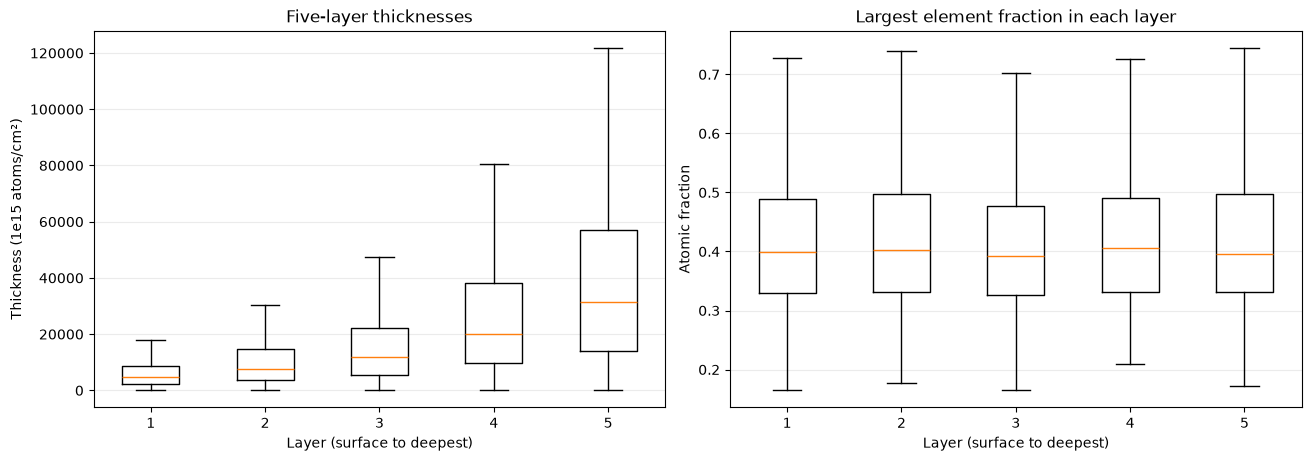

In [3]:
layer_count = 5
dataset = datasets[layer_count]
names = dataset.metadata.parameter_names
values = dataset.parameters

thickness_columns = [names.index(f'layer_{i}_thickness') for i in range(layer_count)]
element_names = ('Li', 'Ni', 'Mn', 'Co', 'O', 'C', 'F', 'P', 'Cu', 'Al')
composition_columns = [
    [names.index(f'layer_{i}_{element}_concentration') for element in element_names]
    for i in range(layer_count)
]
layer_compositions = np.stack([values[:, columns] for columns in composition_columns], axis=1)
composition_sums = layer_compositions.sum(axis=2)
print('Maximum absolute composition-sum error:', np.max(np.abs(composition_sums - 1.0)))
assert np.all(np.isfinite(values))
assert np.all(values[:, thickness_columns] >= 0)
assert np.allclose(composition_sums, 1.0, atol=1e-8)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)
axes[0].boxplot([values[:, column] for column in thickness_columns], showfliers=False)
axes[0].set(title='Five-layer thicknesses', xlabel='Layer (surface to deepest)', ylabel='Thickness (1e15 atoms/cm²)')
axes[0].set_xticks(range(1, layer_count + 1))
axes[0].grid(axis='y', alpha=0.25)

axes[1].boxplot([layer_compositions[:, i, :].max(axis=1) for i in range(layer_count)], showfliers=False)
axes[1].set(title='Largest element fraction in each layer', xlabel='Layer (surface to deepest)', ylabel='Atomic fraction')
axes[1].set_xticks(range(1, layer_count + 1))
axes[1].grid(axis='y', alpha=0.25)
plt.show()

## Inspect representative RBS spectra

Overlay a handful of spectra from the five-layer dataset. Counts should be finite and nonnegative, and the spectra should show variation across the sampled layer systems.

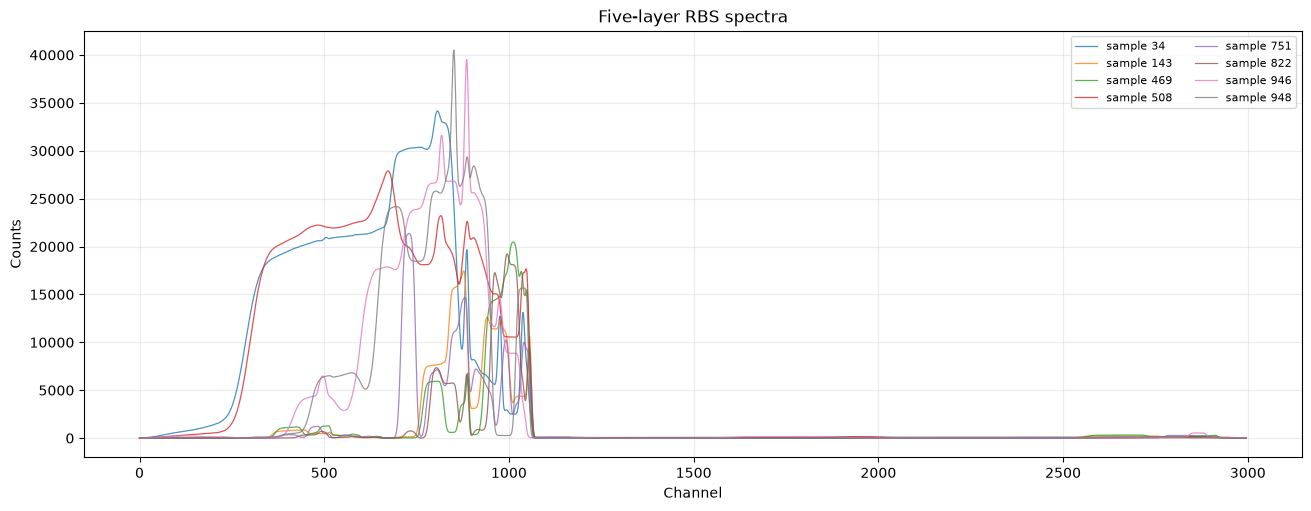

RBS array shape: (1000, 2997)
RBS count range: 0.0 to 57054.32421875


In [4]:
spectra = dataset.spectra('RBS')
assert spectra.shape[0] == dataset.metadata.accepted
assert np.all(np.isfinite(spectra)) and np.all(spectra >= 0)

rng = np.random.default_rng(1)
indices = np.sort(rng.choice(len(spectra), size=min(8, len(spectra)), replace=False))
fig, axis = plt.subplots(figsize=(13, 5), constrained_layout=True)
for index in indices:
    axis.plot(spectra[index], linewidth=0.9, alpha=0.8, label=f'sample {index}')
axis.set(title='Five-layer RBS spectra', xlabel='Channel', ylabel='Counts')
axis.grid(alpha=0.25)
axis.legend(ncols=2, fontsize=8)
plt.show()

print('RBS array shape:', spectra.shape)
print('RBS count range:', float(spectra.min()), 'to', float(spectra.max()))